### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3
rho_steel *= 9.81

In [14]:
# Ar=np.pi*((d0/2)**2-(dI/2)**2)
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.46245685, 0.65633437, 0.6863616 , 0.60385814, 0.73182646,
       0.87262279, 0.75979616, 0.77658258, 0.10340583, 0.23258157,
       0.46280025, 0.29481739, 0.17051026, 0.12861796, 0.18871859,
       0.33026084, 0.40727526, 0.02126337, 0.77867892, 0.40562756])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 12)

coefs = [1, 1, 1, 1, 1, 1]
k500 = 6
lift_reduction_factor=1
vessel_motion_calibration_coefficient = 1e2 # 5e2 # to control dynamics

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.86867845,  0.        ,  0.44334158],
        [ 0.        ,  1.        , -0.44614823],
        [-0.49537637,  0.        ,  0.77743167]],

       [[ 0.55387543,  0.        ,  0.65961399],
        [ 0.        ,  1.        , -0.61021692],
        [-0.83259955,  0.        ,  0.43879915]],

       [[ 0.99536435,  0.        ,  0.07439754],
        [ 0.        ,  1.        , -0.63372688],
        [-0.09617592,  0.        ,  0.76997094]],

       [[ 0.79353887,  0.        ,  0.50090349],
        [ 0.        ,  1.        , -0.56782252],
        [-0.60851957,  0.        ,  0.65320232]],

       [[ 0.84829167,  0.        ,  0.39394602],
        [ 0.        ,  1.        , -0.66822955],
        [-0.52952926,  0.        ,  0.63109096]],

       [[ 0.98856077,  0.        ,  0.09695205],
        [ 0.        ,  1.        , -0.76601755],
        [-0.15082309,  0.        ,  0.6354663 ]],

       [[ 0.98451265,  0.        ,  0.12709821],
        [ 0.        ,  1.        , -0.68877368],
        

In [36]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [37]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.55835333,  0.55804678,  0.63629649],
       [ 0.68762915,  0.57566558, -0.14827252],
       [ 0.28000608, -0.03308662,  0.30026122],
       [ 0.72050581,  0.23937421,  0.08748976],
       [ 0.52974386,  0.39357501,  0.13107599],
       [ 0.05236646,  0.87826593,  0.00848424],
       [ 0.3737273 ,  0.66551382,  0.25578215],
       [ 0.72465499, -0.32846259,  0.13210536],
       [ 0.93331259,  0.64746891,  0.0167679 ],
       [ 0.69101475,  0.28010845,  0.69434469],
       [ 0.96848222, -0.14736606, -0.45950994],
       [ 0.31813236,  0.71197409, -0.14004771],
       [ 1.04606195,  0.2269571 ,  0.046217  ],
       [ 0.33739397,  0.4852637 ,  0.19788984],
       [ 0.61615566,  0.02752191,  0.68329014],
       [ 0.94161065, -0.05175465,  0.35302749],
       [ 0.34766244,  0.49338993, -0.20312579],
       [ 0.6021347 ,  0.29988035,  0.05927132],
       [ 0.24214947,  0.45490735,  0.00891051],
       [ 0.66112371,  0.30619205, -0.11803062]])

In [38]:
def dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ):
    return (np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((ddφ,ddθ,ddψ), axis=1))+
        np.einsum('ijk,ik->ij', Π(dφ,dθ,dψ), np.stack((dφ,dθ,dψ), axis=1)))

In [39]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 1.2017283 ,  1.50681697,  0.85202102],
       [ 1.27256402,  0.91716866, -0.21314326],
       [ 0.77234003,  0.08894117,  0.66830429],
       [ 1.33363112,  0.17995292,  0.0778523 ],
       [ 1.50089425,  0.87616656,  0.39437534],
       [ 0.90264906,  0.43965092,  0.32660681],
       [ 1.08299455,  1.29464199, -0.12015006],
       [ 0.94915587,  0.44171987,  0.37616229],
       [ 1.19804551,  0.39109478, -0.15128771],
       [ 1.74763976,  0.14408065,  0.55725155],
       [ 2.08560902, -0.26853097,  0.0024692 ],
       [ 1.20263098,  1.21708426, -0.17724036],
       [ 1.46717118,  0.16018218,  0.17076396],
       [ 1.39928812,  1.05874436,  0.28645264],
       [ 0.69095162,  0.42629003,  0.98424033],
       [ 1.84822458,  0.53457321,  0.31131997],
       [ 0.79970778,  0.80945529, -0.20146649],
       [ 1.22633027,  0.55191483,  0.39047538],
       [ 1.09866572,  1.27363658,  0.0384852 ],
       [ 1.46435022,  0.96851536, -0.27757803]])

In [40]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [41]:
phi(x,y,z)

array([[0.32600211, 0.71024253, 0.8276873 ],
       [0.11121428, 0.18678231, 0.06269702],
       [0.62997659, 0.26308851, 0.74842882],
       [0.01892206, 0.92321964, 0.41135458],
       [0.72886508, 0.60088552, 0.10307203],
       [0.20085434, 0.81123866, 0.34827751],
       [0.75330771, 0.39635771, 0.52087227],
       [0.18481873, 0.54239321, 0.62690626],
       [0.71809512, 0.50103832, 0.83235339],
       [0.68800318, 0.85060744, 0.56097752],
       [0.75689669, 0.78123254, 0.31179713],
       [0.21103333, 0.15983644, 0.53257721],
       [0.95621511, 0.76671679, 0.47194597],
       [0.49180122, 0.86238264, 0.76956096],
       [0.39044622, 0.3698026 , 0.79696097],
       [0.50176813, 0.29882247, 0.03626182],
       [0.60079304, 0.91630261, 0.44916598],
       [0.88136164, 0.83236631, 0.98116763],
       [0.03811139, 0.10288725, 0.16650016],
       [0.85995725, 0.97417994, 0.89943714]])

In [42]:
theta(φ,θ,ψ)

array([[0.46245685, 0.51826804, 0.13391845],
       [0.65633437, 0.98378465, 0.95508423],
       [0.6863616 , 0.09632481, 0.21341283],
       [0.60385814, 0.65419364, 0.78037089],
       [0.73182646, 0.55804554, 0.50127023],
       [0.87262279, 0.15140083, 0.0655606 ],
       [0.75979616, 0.17622427, 0.19196956],
       [0.77658258, 0.33490046, 0.59231895],
       [0.10340583, 0.56951745, 0.94191141],
       [0.23258157, 0.29558903, 0.81237455],
       [0.46280025, 0.91804552, 0.49046716],
       [0.29481739, 0.74885953, 0.59756973],
       [0.17051026, 0.45294931, 0.10807549],
       [0.12861796, 0.74193823, 0.64869449],
       [0.18871859, 0.20790161, 0.91140371],
       [0.33026084, 0.31737673, 0.43903495],
       [0.40727526, 0.80314059, 0.02712625],
       [0.02126337, 0.5224862 , 0.71392606],
       [0.77867892, 0.01961002, 0.21830286],
       [0.40562756, 0.99687958, 0.03246661]])

In [43]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [44]:
ω(x,y,z)

array([[ 0.75841868,  0.44516883,  0.3819433 ],
       [ 0.12085071,  0.17982387,  0.04057363],
       [ 0.76557665, -0.17783025,  0.42011814],
       [ 0.33943114,  0.91543642,  0.23301623],
       [ 0.64466212,  0.53223713, -0.34866358],
       [ 0.3857815 ,  0.74175501,  0.0893552 ],
       [ 0.84158622,  0.0400523 ,  0.05966173],
       [ 0.47638269,  0.42718768,  0.43238483],
       [ 0.93091081, -0.04660974,  0.20484001],
       [ 0.77950788,  0.49438903, -0.23134402],
       [ 0.69704054,  0.5671312 , -0.37202842],
       [ 0.29122613,  0.04827727,  0.48053662],
       [ 0.8774569 ,  0.38112985, -0.46741036],
       [ 0.83512031,  0.49898487,  0.06788703],
       [ 0.63041967,  0.06647839,  0.54604075],
       [ 0.48889107,  0.28138138, -0.117335  ],
       [ 0.65968492,  0.66239051, -0.25109123],
       [ 1.05482339,  0.07529174, -0.23167641],
       [ 0.05499796,  0.09654324,  0.16158514],
       [ 0.96863536,  0.29257328, -0.38166939]])

In [45]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])


        return np.array(np.dot(np.dot(Cθ,Cφ),Cψ) )
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [46]:
Ret(φ,θ,ψ)

array([[[ 0.89040968,  0.10304776,  0.44334158],
        [ 0.11949362,  0.8869459 , -0.44614823],
        [-0.43919457,  0.4502312 ,  0.77743167]],

       [[ 0.73465146, -0.15873444,  0.65961399],
        [ 0.64675035,  0.45754704, -0.61021692],
        [-0.20494199,  0.87490233,  0.43879915]],

       [[ 0.98569214, -0.15124817,  0.07439754],
        [ 0.16383667,  0.7560078 , -0.63372688],
        [ 0.03960491,  0.63684865,  0.76997094]],

       [[ 0.80702651, -0.31273615,  0.50090349],
        [ 0.57912217,  0.58497444, -0.56782252],
        [-0.11543711,  0.74833215,  0.65320232]],

       [[ 0.91396643, -0.09732367,  0.39394602],
        [ 0.35750012,  0.65242849, -0.66822955],
        [-0.19198705,  0.75157513,  0.63109096]],

       [[ 0.99400602,  0.05052071,  0.09695205],
        [ 0.04211346,  0.64143867, -0.76601755],
        [-0.10088854,  0.76550904,  0.6354663 ]],

       [[ 0.98946598, -0.06930455,  0.12709821],
        [ 0.13832017,  0.71165887, -0.68877368],
        

In [47]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [48]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[ 0.46827616, -0.4223879 ,  0.17801269],
       [ 0.04893113, -0.07645615,  0.14097664],
       [-0.05499362, -0.46126146,  0.20843303],
       [-0.0445269 , -0.35521727,  0.79927661],
       [ 0.06576239, -0.13621934,  0.32909337],
       [ 0.10820982, -0.32071894,  0.68464138],
       [ 0.02140648, -0.39946212,  0.2730117 ],
       [-0.12828459, -0.52027872,  0.48795978],
       [ 0.02572982,  0.03355823, -0.04239836],
       [-0.52483527,  0.21967268,  0.31058841],
       [ 0.29694866, -0.27287049, -0.03715285],
       [ 0.27149191, -0.27629899, -0.02465595],
       [ 0.18889709, -0.07413097, -0.26229442],
       [ 0.17290738, -0.21701192,  0.13268767],
       [-0.28009639,  0.03237497,  0.12220201],
       [-0.08076104,  0.13018817,  0.04467968],
       [ 0.60859139, -0.30075979, -0.20048379],
       [-0.00826223,  0.16823491, -0.13529906],
       [-0.03667752, -0.12479324,  0.08551022],
       [ 1.20117223, -0.49961806, -0.6073119 ]])

In [49]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 0.12617634, -0.11954634,  0.02692634],
       [ 0.50827408, -1.03248958,  0.71422982],
       [-0.01777588, -0.08171143,  0.09405019],
       [ 0.07164278, -0.59306424,  0.44173454],
       [ 0.15154403, -0.46226603,  0.29337783],
       [ 0.02025196, -0.13546448,  0.04327465],
       [ 0.00777443, -0.14538373,  0.10268899],
       [-0.09567408, -0.40501711,  0.35443613],
       [ 0.02726119, -0.48204804,  0.28847278],
       [-0.11548659, -0.20769462,  0.108635  ],
       [ 0.43568343, -0.35565427,  0.25459892],
       [ 0.18041016, -0.29736022,  0.28363716],
       [ 0.03739115, -0.01800093,  0.01645085],
       [ 0.13994052, -0.29368266,  0.3081505 ],
       [-0.14036115, -0.17874855,  0.06983828],
       [-0.01568345, -0.09838557,  0.08292032],
       [ 0.24296406, -0.12046617, -0.08117512],
       [ 0.04454779, -0.25452506,  0.18494716],
       [-0.0319372 , -0.06152873,  0.11944601],
       [ 0.35537864, -0.13956583, -0.15465269]])

In [50]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [51]:
ne(x, y, z, φ, θ, ψ)

array([[ 4.68276155e+08, -4.22387905e+08,  1.78012688e+08],
       [ 4.89311313e+07, -7.64561494e+07,  1.40976643e+08],
       [-5.49936207e+07, -4.61261464e+08,  2.08433026e+08],
       [-4.45268991e+07, -3.55217266e+08,  7.99276609e+08],
       [ 6.57623903e+07, -1.36219342e+08,  3.29093369e+08],
       [ 1.08209818e+08, -3.20718945e+08,  6.84641379e+08],
       [ 2.14064779e+07, -3.99462117e+08,  2.73011702e+08],
       [-1.28284592e+08, -5.20278718e+08,  4.87959776e+08],
       [ 2.57298231e+07,  3.35582322e+07, -4.23983624e+07],
       [-5.24835274e+08,  2.19672684e+08,  3.10588408e+08],
       [ 2.96948657e+08, -2.72870489e+08, -3.71528479e+07],
       [ 2.71491912e+08, -2.76298992e+08, -2.46559456e+07],
       [ 1.88897093e+08, -7.41309735e+07, -2.62294419e+08],
       [ 1.72907377e+08, -2.17011917e+08,  1.32687670e+08],
       [-2.80096389e+08,  3.23749659e+07,  1.22202006e+08],
       [-8.07610424e+07,  1.30188172e+08,  4.46796824e+07],
       [ 6.08591395e+08, -3.00759786e+08

In [52]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 2.88333880e+07, -1.40605380e+08, -4.09476430e+08],
       [ 4.67897710e+07, -1.46294857e+08, -9.55804988e+07],
       [ 3.72343704e+07, -1.51113056e+08, -3.24588564e+08],
       [ 2.19253005e+08, -7.01766238e+08, -2.99667006e+08],
       [ 6.37191902e+07, -2.73969840e+08, -1.26135381e+08],
       [ 4.04234892e+07, -6.04684714e+08, -2.89652463e+08],
       [ 1.35368083e+07, -2.10800187e+08, -3.09497591e+08],
       [ 3.56659127e+07, -4.44096591e+08, -4.64133785e+08],
       [-4.46308063e+07,  4.39777222e+07,  7.72369124e+06],
       [-1.17586569e+08, -5.01956341e+08,  1.56324306e+08],
       [-5.35586904e+07, -6.62366360e+06, -3.79426602e+08],
       [ 4.60786400e+07,  7.41352067e+07, -3.23390752e+08],
       [-1.12428084e+08,  5.64345596e+07, -9.69173774e+07],
       [ 1.71461691e+08, -3.28891926e+06, -2.28813468e+08],
       [-2.25856456e+07, -2.79584060e+08,  2.23021432e+07],
       [-3.01308937e+07, -4.33517184e+07,  7.18554483e+07],
       [-2.41798234e+08, -1.07525220e+08

In [53]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [54]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 4610979.22735887,  4585205.58195706, -1249777.4777032 ],
       [ 9935143.98589848,  4009760.85687751, -1273735.53775642],
       [ 6990572.63840718,  -389206.4255134 ,   983102.23792401],
       [ 8700754.12756933,  2110814.73002974,  1422805.85569927],
       [ 8182757.03504952,  2230819.64241348,  -711764.19778932],
       [ 8689968.89893438,  1011802.62192405,  -899501.11903433],
       [ 7724279.18309923,   440006.88930232,    38153.93832496],
       [ 8723061.15340096,  -802238.02007095,  1437919.68861751],
       [ 5922742.20405536,  4722918.0366164 ,  7332450.39727962],
       [ 4527703.09949403,  1083445.41022982,  6884657.90359728],
       [ 6297404.81443375,  6990737.43237685, -1010959.8143182 ],
       [ 6052189.32068183,  5752266.05394993,  2181021.20036052],
       [ 1999261.15696515,  4346104.98171607,   211493.74071561],
       [ 5295259.73016216,  6587343.08699269,  3873325.0841927 ],
       [ 3694350.16162456,   369219.22362353,  8369917.26458923],
       [ 4

In [55]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-2.32830644e-10,  1.26317004e-10, -4.65661287e-10],
       [ 0.00000000e+00,  1.19143659e-10,  9.31322575e-10],
       [ 0.00000000e+00,  2.15450794e-10,  5.82076609e-11],
       [ 1.16415322e-10, -1.82242575e-10, -2.32830644e-10],
       [ 1.45519152e-10, -5.97050456e-10, -4.65661287e-10],
       [ 1.45519152e-11,  8.12895005e-11,  1.16415322e-10],
       [-6.36646291e-12,  1.09352498e-10,  5.82076609e-11],
       [ 2.91038305e-11,  6.37241669e-10,  2.32830644e-10],
       [-4.65661287e-10,  5.06218164e-10, -4.65661287e-10],
       [ 4.65661287e-10,  2.20118812e-10, -2.91038305e-10],
       [-6.98491931e-10,  4.61552927e-10,  0.00000000e+00],
       [ 0.00000000e+00, -6.32598519e-10,  1.86264515e-09],
       [-2.91038305e-11,  1.85812659e-11, -1.16415322e-10],
       [ 4.65661287e-10,  3.35978827e-10, -9.31322575e-10],
       [-1.74622983e-10,  5.17531078e-10,  8.73114914e-11],
       [-1.16415322e-10,  2.73893113e-10,  1.16415322e-10],
       [ 0.00000000e+00, -8.22520687e-11

In [56]:
def fD(dx,dy,dz): 
    
    A=np.vstack([np.abs(dx-dv1_curr)*dx-(dv1_curr),
                 ((dy-dv2_curr)**2+(dz-dv3_curr)**2)**0.5*(dy-dv2_curr),
                 ((dy-dv2_curr)**2+(dz-dv3_curr)**2)**0.5*(dz-dv3_curr)])
    
    return 1/2*d0*qw*np.dot(DT, A)*9.81

In [57]:
fD(dx,dy,dz).T

array([[1907.47254866, 3540.28204878, 2284.12678115],
       [ 409.17334381,  835.06272086, 2708.90302641],
       [  86.84170094, 4550.39967627, 4465.29871604],
       [ 394.24690362,  598.66807084, 2925.3892565 ],
       [  86.49716843,  438.02482768, 3643.52147278],
       [ 525.84188635,  340.52708991,   21.69206098],
       [ 111.02689531, 3513.17551364, 2647.71766844],
       [3340.37910199, 1178.05030865, 1226.12917468],
       [1187.04092265,  694.79851589, 2262.61149001],
       [1345.74706224,  221.02295034, 1454.15681083],
       [3106.91310674,   84.7177829 ,   75.61279943],
       [3573.54508747,  116.8803276 ,  101.12569248],
       [  15.48650613,  419.9310428 , 1778.11082483],
       [2601.32533618,   36.88530607,  851.09106352],
       [1157.28120038,  615.43645534,   27.78811279],
       [1507.4489314 ,  406.98771901, 3030.64327764],
       [2356.85335404,  995.92985551,  935.80984215],
       [ 986.40986554,  479.2739507 , 2214.64683458],
       [2846.37226797, 3184.

In [58]:
fg_e = lift_reduction_factor*np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [59]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [60]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [61]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 25895.64503167],
       [ 5845.36330569,  5845.36330569,  7364.16501662],
       [ 5845.36330569,  5845.36330569, 23975.65077536],
       [ 5845.36330569,  5845.36330569, 15810.20783358],
       [ 5845.36330569,  5845.36330569,  8342.22797325],
       [ 5845.36330569,  5845.36330569, 14282.19954273],
       [ 5845.36330569,  5845.36330569, 18463.21515087],
       [ 5845.36330569,  5845.36330569, 21031.83187394],
       [ 5845.36330569,  5845.36330569, 26008.6785181 ],
       [ 5845.36330569,  5845.36330569, 19434.74347205],
       [ 5845.36330569,  5845.36330569, 13398.48184948],
       [ 5845.36330569,  5845.36330569, 18746.76101587],
       [ 5845.36330569,  5845.36330569, 17278.00175608],
       [ 5845.36330569,  5845.36330569, 24487.5655925 ],
       [ 5845.36330569,  5845.36330569, 25151.31600074],
       [ 5845.36330569,  5845.36330569,  6723.78648559],
       [ 5845.36330569,  5845.36330569, 16726.16871693],
       [ 5845.36330569,  5845.3

In [62]:
def ne_hat(x,y,z,dx,dy,dz):
    return -fg_e.T - fD(dx,dy,dz) #- sigma(x,y,z).T

In [63]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-1907.47254866, -3540.28204878, -2008.95562947],
       [ -409.17334381,  -835.06272086, -2433.73187473],
       [  -86.84170094, -4550.39967627, -4190.12756436],
       [ -394.24690362,  -598.66807084, -2650.21810483],
       [  -86.49716843,  -438.02482768, -3368.3503211 ],
       [ -525.84188635,  -340.52708991,   253.4790907 ],
       [ -111.02689531, -3513.17551364, -2372.54651676],
       [-3340.37910199, -1178.05030865,  -950.958023  ],
       [-1187.04092265,  -694.79851589, -1987.44033833],
       [-1345.74706224,  -221.02295034, -1178.98565916],
       [-3106.91310674,   -84.7177829 ,   199.55835225],
       [-3573.54508747,  -116.8803276 ,   174.0454592 ],
       [  -15.48650613,  -419.9310428 , -1502.93967315],
       [-2601.32533618,   -36.88530607,  -575.91991185],
       [-1157.28120038,  -615.43645534,   247.38303888],
       [-1507.4489314 ,  -406.98771901, -2755.47212596],
       [-2356.85335404,  -995.92985551,  -660.63869047],
       [ -986.40986554,  -479.2

In [64]:
def Jrho(Ret,Jrho0): 
    ans=  Ret @ Jrho0 @ Ret
    return ans

In [65]:
RET = Ret(φ, θ, ψ)

In [66]:
Jrho(RET,Jrho0)

array([[[  41.57165331,   58.23649251,  103.81166197],
        [  60.42744111,   39.724687  , -103.64323911],
        [-102.01508737,  105.4120682 ,   81.32169353]],

       [[  16.66860141,   96.49526697,  116.03249335],
        [ 102.11729316,  -96.10726759,  -38.81227058],
        [  23.54257194,  120.06531209,  -28.39734164]],

       [[  95.27020173,  -16.86689742,   28.3750994 ],
        [  23.51569283,  -26.04084138, -144.28159762],
        [  20.43666585,  145.61822814,   78.50689048]],

       [[  35.45336483,   31.43553531,  123.62036781],
        [  93.72341923,  -68.87570325,  -78.3883329 ],
        [  18.94073436,  145.14811282,   37.06038436]],

       [[  64.92763429,   43.97127651,   92.23195296],
        [  81.65692139,  -61.35797215, -113.85635061],
        [ -14.91041148,  145.76584425,   21.86943412]],

       [[  97.06128589,   23.10591623,   18.08906861],
        [  22.34390238,  -75.92155437, -146.08269644],
        [ -19.62681195,  145.88405278,   21.14601197]],

### Static solution

In [67]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [68]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [69]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [70]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [71]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [72]:
delta_x=horizontal_length/(N-1)

In [73]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [74]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [75]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

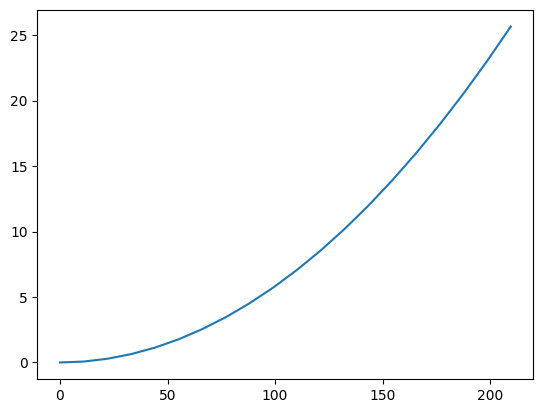

In [76]:
plt.plot(x0, z0)
plt.show()

In [77]:
q0=np.zeros(12*N)

In [78]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [79]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
#     ddx,ddy, ddz = (Z/Ws[0]).T
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', Π(dφ,dθ,dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [80]:
root_ = root(static_func, q0, method='df-sane')

In [81]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 1.989e+01  1.989e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.006e+02  1.116e+02 ...  0.000e+00  0.000e+00]
     nit: 431
    nfev: 1000
  method: df-sane

In [82]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [83]:
# q0 = root_.x                                            # start from static solution

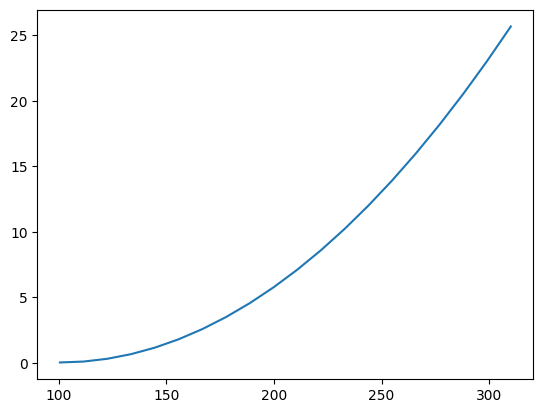

In [84]:
plt.plot(x0_, z0_)
plt.show()

### Finite Element Model of the Space Frame Element

In [85]:
def PlaneTrussElementLength(x1,y1,z1,x2,y2,z2):
    return np.sqrt((x2-x1)*(x2-x1) + (y2-y1)*(y2-y1)+(z2-z1)*(z2-z1))

In [86]:
def SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,x1,y1,z1,x2,y2,z2):
    L = PlaneTrussElementLength(x1,y1,z1,x2,y2,z2)
    w1 = E*A/L
    w2 = 12*E*Iz/(L*L*L)
    w3 = 6*E*Iz/(L*L)
    w4 = 4*E*Iz/L
    w5 = 2*E*Iz/L
    w6 = 12*E*Iy/(L*L*L)
    w7 = 6*E*Iy/(L*L)
    w8 = 4*E*Iy/L
    w9 = 2*E*Iy/L
    w10 = G*J/L

    kprime = np.array([[w1, 0, 0, 0, 0, 0, -w1, 0, 0, 0, 0, 0],
                        [0, w2, 0, 0, 0, w3, 0, -w2, 0, 0, 0, w3],
                        [0, 0, w6, 0, -w7, 0, 0, 0, -w6, 0, -w7, 0],
                        [0, 0, 0, w10, 0, 0, 0, 0, 0, -w10, 0, 0],
                        [0, 0, -w7, 0, w8, 0, 0, 0, w7, 0, w9, 0],
                        [0, w3, 0, 0, 0, w4, 0, -w3, 0, 0, 0, w5],
                        [-w1, 0, 0, 0, 0, 0, w1, 0, 0, 0, 0, 0],
                        [0, -w2, 0, 0, 0, -w3, 0, w2, 0, 0, 0, -w3],
                        [0, 0, -w6, 0, w7, 0, 0, 0, w6, 0, w7, 0],
                        [0, 0, 0, -w10, 0, 0, 0, 0, 0, w10, 0, 0],
                        [0, 0, -w7, 0, w9, 0, 0, 0, w7, 0, w8, 0],
                        [0, w3, 0, 0, 0, w5, 0, -w3, 0, 0, 0, w4]])


    if x1 == x2 and y1 == y2:
        if z2 > z1:
            Lambda = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]])
        else:
            Lambda = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]])
    else:
        CXx = (x2-x1)/L
        CYx = (y2-y1)/L
        CZx = (z2-z1)/L
        D = np.sqrt(CXx*CXx + CYx*CYx)
        CXy = -CYx/D
        CYy = CXx/D
        CZy = 0
        CXz = -CXx*CZx/D
        CYz = -CYx*CZx/D
        CZz = D
        Lambda = np.array([[CXx, CYx, CZx], [CXy, CYy, CZy], [CXz, CYz, CZz]])


    R = np.array([np.concatenate((np.concatenate((Lambda,np.zeros((3,3)),np.zeros((3,3)),np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), Lambda, np.zeros((3,3)), np.zeros((3,3))),axis=1) ,
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), Lambda, np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3)), Lambda),axis=1)))])[0]
    return np.dot(np.dot(R.T,kprime),R)

In [87]:
def SpaceFrameAssemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]

    return K

In [88]:
def FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs,
          E=210e6, G=84e6, A=2e-2, Iy=10e-5, Iz=20e-5, J=5e-5):

    coord=np.array(coord)
    elcon=np.array(elcon)

    K=np.zeros(shape=(6*(np.max(elcon)+1),6*(np.max(elcon)+1)))

    for el in elcon:
        k=SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,
                                     coord[el[0]][0],coord[el[0]][1],coord[el[0]][2],\
                                     coord[el[1]][0],coord[el[1]][1],coord[el[1]][2])
        K=SpaceFrameAssemble(K,k,el[0],el[1])
        
        
    glob_force=np.dot(K, np.array(vessel_movement))
    
    glob_force[-6:]=np.multiply(glob_force[-6:], coefs)
    glob_force = np.zeros(len(vessel_movement))


    F=np.zeros(len(coord)*6)
    for i in range(len(vessel_movement)):
        if vessel_movement[i]:
            F[i]=glob_force[i]

    # https://github.com/CALFEM/calfem-matlab/blob/master/fem/solveq.m

    bc=np.array([bc_node,
                bc_val]).T
    nd, nd=K.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    s=scipy.linalg.lstsq(K[fdof,:][:,fdof], (F[fdof].T-np.dot(K[fdof,:][:,pdof],dp.T)).T, check_finite=True)[0]
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    

#     Q=np.dot(K,d).T-F
    return d, np.dot(K,d).T

In [89]:
# 10 The Space Frame Element - verification
d,f=FEA(np.array([0,0,0,
                  3,0,0,
                  0,0,-3,
                  0,-4,0]).reshape(4,3),
        elcon=np.array([[0, 1],
                      [0, 2],
                      [0, 3]]),
        bc_node=list(range(6)),
        bc_val=[ -0.0705e-4, -0.0007e-4, 0.1418e-4, 0.0145e-4, 0.0175e-4,0.0114e-4],
        vessel_movement=[ 0, 0, 0, 0, 0,0.0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                       ],
        coefs=[1,1,1,1,1,1])

In [90]:
d

array([-7.050e-06, -7.000e-08,  1.418e-05,  1.450e-06,  1.750e-06,
        1.140e-06, -7.050e-06,  3.350e-06,  8.930e-06,  1.450e-06,
        1.750e-06,  1.140e-06, -1.230e-05,  4.280e-06,  1.418e-05,
        1.450e-06,  1.750e-06,  1.140e-06, -2.490e-06, -7.000e-08,
        8.380e-06,  1.450e-06,  1.750e-06,  1.140e-06])

In [91]:
f

array([ 2.18575158e-15, -1.86923231e-17, -3.84067778e-15,  9.71445147e-17,
        4.94078553e-17, -1.38777878e-17, -5.59719372e-16, -2.94360890e-17,
        2.29749217e-17,  3.06625927e-19,  2.51331616e-17,  5.88721780e-17,
        1.93123512e-17,  1.42708111e-17,  1.72398987e-15, -2.85416222e-17,
        6.63802780e-17, -6.09863722e-20,  2.08166817e-17,  4.64478987e-17,
        2.42861287e-17,  1.38777878e-17,  3.17637355e-20, -1.38777878e-17])

In [92]:
def PipeForce(X,Y,Z,vessel_movement,coefs, E=E, G=G, A=Ar, Iy=Iy_, Iz=Iz_, J=J_):
    coord=np.stack((X,Y,Z)).T
    elcon=[]
    for i in range(1,len(X)):
        elcon.append([i-1,i])
    
    bc_node = list(range(3))+list(range((6*len(X)-6),6*len(X)))
    bc_val = [0]*3 + vessel_movement
    
    vessel_move=np.zeros(len(X)*6)

    d, f = FEA(coord,elcon,bc_node,bc_val,vessel_move, coefs, E,G,A,Iy,Iz,J)

    fors=[]
    for i in range(0,len(f),6):
        fors.append(f[i:i+3])

    mom =[]
    for i in range(3,len(f),6):
        mom.append(f[i:i+3])

    angle=[]
    for i in range(3,len(d),6):
        angle.append(d[i:i+3])
    fors[0][0]=0
    fors[0][1]=0
    fors[0][2]=0
    return np.array(fors), np.array(mom), np.array(angle)

In [93]:
fors, mom, angle = PipeForce(x0_,list([0 for i in range(len(z0))]),z0_,
[0.01,
 0.02,
 0.03,
 0.01,
 -0.05,
 0.03],
 [1,1,1,1,1,1]
)

In [94]:
fors

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.84855270e-03, -3.11279297e-03,  2.07519531e-03],
       [-5.24330139e-03, -1.55639648e-03, -2.50244141e-03],
       [-4.16374207e-03,  1.66320801e-03,  1.89208984e-03],
       [ 2.63929367e-04,  1.09863281e-03, -3.28063965e-04],
       [ 2.61306763e-03,  4.88281250e-03,  4.94384766e-03],
       [ 1.06811523e-04, -1.34277344e-03, -2.44140625e-04],
       [-2.74658203e-03, -5.80596924e-03, -1.70898438e-03],
       [-2.72274017e-04, -7.44628906e-03,  1.46484375e-03],
       [ 2.21252441e-04, -3.66210938e-03, -2.25830078e-03],
       [-1.67846680e-04, -1.58691406e-03,  1.09863281e-03],
       [ 0.00000000e+00,  8.08715820e-04, -5.49316406e-04],
       [-2.20775604e-04, -7.32421875e-04,  1.00135803e-03],
       [ 5.11169434e-04,  1.46484375e-03, -3.90625000e-03],
       [-1.83105469e-04, -3.66210938e-04,  1.09863281e-03],
       [-1.99250853e-04,  6.77083576e-04,  4.97201975e-04],
       [ 3.69392116e-04,  8.50747735e-04

In [95]:
mom

array([[ 1.95789337e-03,  5.91313839e-03, -1.46484375e-03],
       [-3.71360779e-03,  1.61132812e-02, -7.77435303e-03],
       [-6.70242310e-03,  9.75036621e-03,  2.80761719e-03],
       [-1.17492676e-03,  3.29589844e-03, -1.26953125e-02],
       [-4.82177734e-03, -2.70080566e-03, -7.81250000e-03],
       [ 3.31497192e-03, -1.70898438e-03, -1.01318359e-02],
       [-3.66210938e-04, -6.36291504e-03,  1.95312500e-03],
       [ 1.14440918e-03, -1.56250000e-02,  1.83105469e-03],
       [ 1.09863281e-03, -6.82830811e-04, -5.37109375e-03],
       [ 2.98500061e-03, -2.05078125e-02, -5.98144531e-03],
       [ 3.05175781e-03,  1.78909302e-02, -1.36718750e-02],
       [ 3.66210938e-04,  9.76562500e-04,  9.76562500e-04],
       [ 1.15966797e-03, -9.14764404e-03, -1.02539062e-02],
       [ 1.67083740e-03,  1.24511719e-02, -1.48315430e-02],
       [ 3.05175781e-04,  1.84173584e-02, -2.19726562e-03],
       [-1.64723926e-03,  1.00066882e-02,  1.19107671e-02],
       [ 2.47373481e-04,  1.22879062e-02

In [96]:
angle

array([[-3.79148721e-01,  2.40891300e-02, -4.15794652e-02],
       [-3.79148721e-01,  2.39020854e-02, -4.15793984e-02],
       [-3.78804376e-01,  2.33382763e-02, -4.15725701e-02],
       [-3.77771511e-01,  2.23922560e-02, -4.15390978e-02],
       [-3.75706289e-01,  2.10583820e-02, -4.14458503e-02],
       [-3.72265384e-01,  1.93308104e-02, -4.12464567e-02],
       [-3.67106146e-01,  1.72034896e-02, -4.08813186e-02],
       [-3.59886769e-01,  1.46701539e-02, -4.02776266e-02],
       [-3.50266455e-01,  1.17243172e-02, -3.93493795e-02],
       [-3.37905578e-01,  8.35926695e-03, -3.79974073e-02],
       [-3.22465845e-01,  4.56805748e-03, -3.61093967e-02],
       [-3.03610455e-01,  3.43503427e-04, -3.35599207e-02],
       [-2.81004254e-01, -4.32182685e-03, -3.02104696e-02],
       [-2.54313887e-01, -9.43561796e-03, -2.59094864e-02],
       [-2.23207949e-01, -1.50058143e-02, -2.04924032e-02],
       [-1.87357131e-01, -2.10406272e-02, -1.37816809e-02],
       [-1.46434359e-01, -2.75485414e-02

### Vessle Simulation

In [97]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [98]:
Number*sampleTime

600.0

In [99]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [100]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [101]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

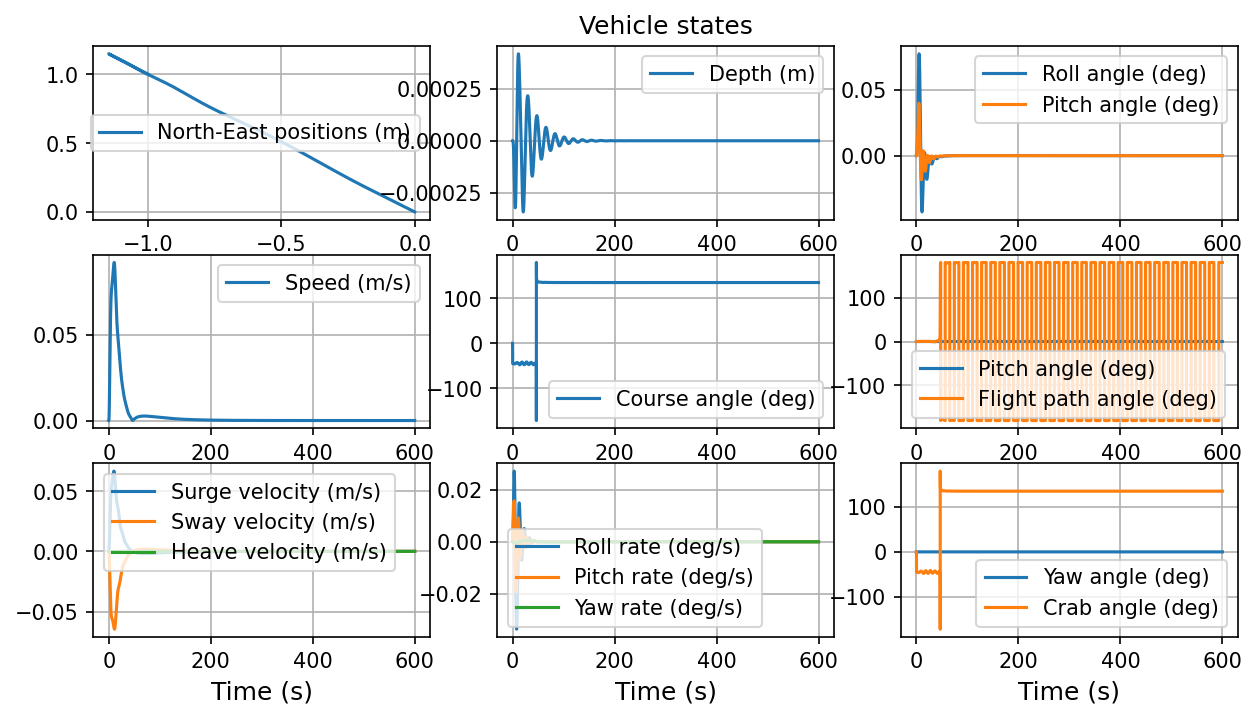

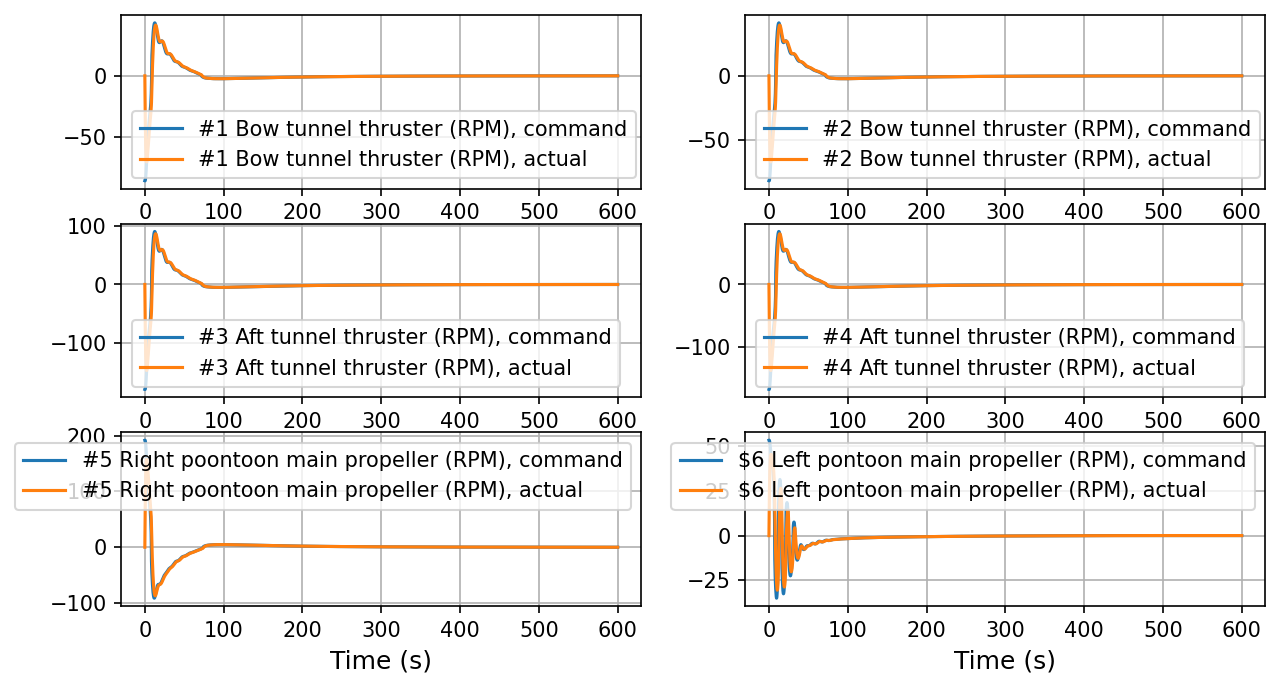

In [102]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [103]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

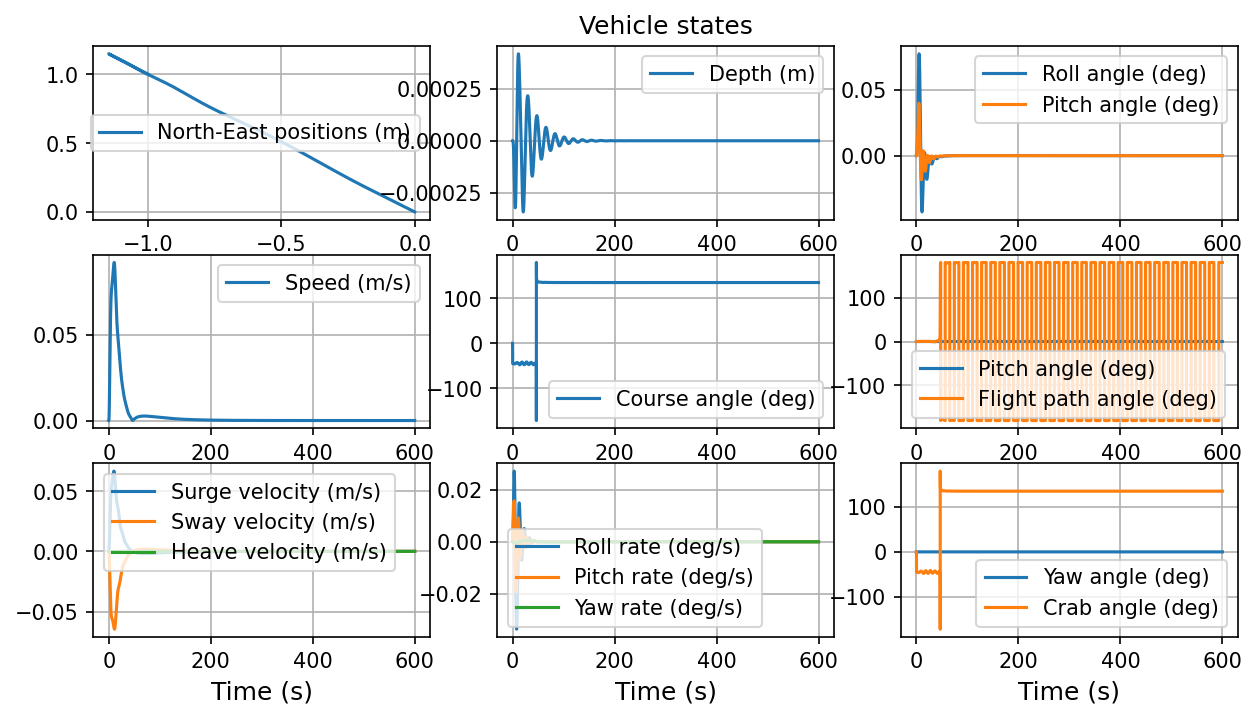

In [104]:
plotVehicleStates(simTime, simData, 3)

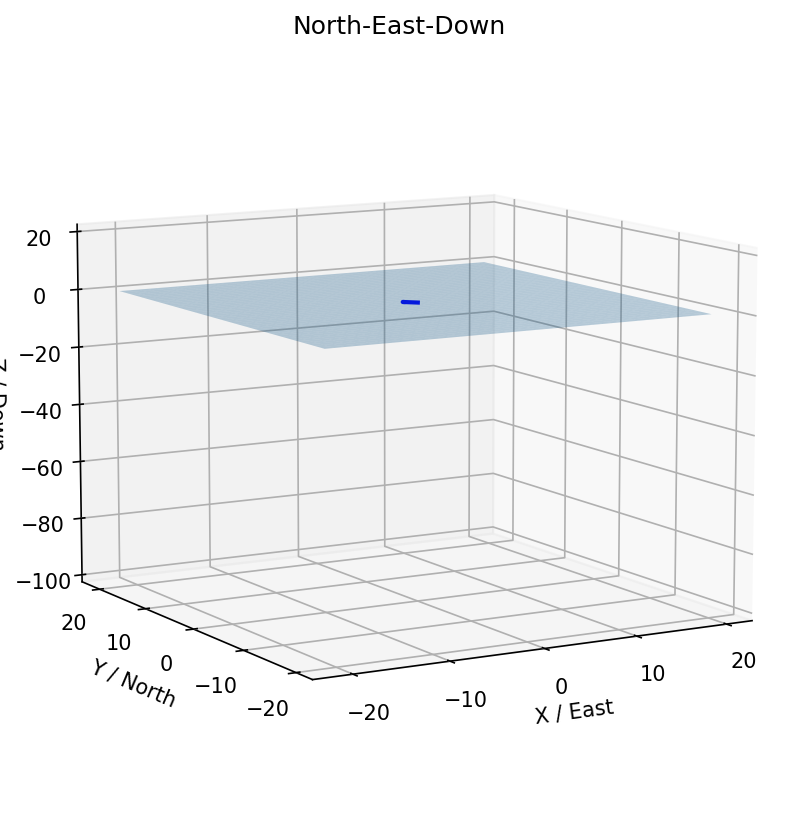

In [105]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [106]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [107]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

In [108]:
def inert(M, m, X):
    sum_=M
    ans=[]
    for i in range(len(X)-1,-1,-1):
        sum_+=m
        ans.append(np.array(sum_).copy())
    return np.array(ans)  

In [109]:
# V_rho=np.zeros(Jrho0.shape)
# np.fill_diagonal(V_rho, vessel_inertia)

In [110]:
# M_t=inert(vessel_mass*9.81,mp*9.81, x0)
# Jrho1=inert(V_rho, Jrho0, x0)

### Dynamics

In [111]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    del_t = idx-T.my_t
    if del_t<0:
        idx=T.my_t
        
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    
    RET = Ret(φ,θ,ψ)

    vessel_movement = np.zeros(6)
    
    
    vessel_movement[0] = (x_ve - T.x_ve)
    vessel_movement[1] = (y_ve - T.y_ve)
    vessel_movement[2] = (z_ve - T.z_ve)
    vessel_movement[3] = (phi_ve - T.phi_ve)
    vessel_movement[4] = (theta_ve - T.theta_ve)
    vessel_movement[5] = (psi_ve - T.psi_ve)

    vessel_movement/=calibr
    

    fors, mom, angle = PipeForce(x, y, z, list(vessel_movement), coefs)
    
    Z0 = fors.squeeze()
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T

    Z = (Z1 + Z2 - Z0)


############################################################
#     ddx,ddy, ddz = (Z/(M_t.reshape(-1, 1))).T
#     ddx,ddy, ddz = (Z/Ws[0]).T
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,ik->ij', Π(φ,θ,ψ), angle).squeeze()    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0)

    A0 = Jrho(RET,Jrho0)
#     A0 = Jrho(RET,Jrho1) 
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', Π(dφ,dθ,dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################

    T.my_t=idx
    T.x_ve=x_ve
    T.y_ve=y_ve
    T.z_ve=z_ve
    T.phi_ve = phi_ve
    T.theta_ve = theta_ve
    T.psi_ve = psi_ve

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [112]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.000001 for i in range(N)]),
                                          np.array([0.001257*i/N for i in range(N)]))

In [113]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.965441609457437e-08  Iteration wall-clock time:  0:00:00.497661
Physical time:  1.0055967372439578  Iteration wall-clock time:  0:01:10.075489
Physical time:  2.0102875665086297  Iteration wall-clock time:  0:03:05.649288
Physical time:  3.008863602132205  Iteration wall-clock time:  0:03:19.273369
Physical time:  4.00859900250467  Iteration wall-clock time:  0:02:59.425083
Physical time:  5.0000282105818705  Iteration wall-clock time:  0:03:29.489369
Physical time:  6.004527950188323  Iteration wall-clock time:  0:03:34.786933
Physical time:  7.019207494204765  Iteration wall-clock time:  0:03:03.302141
Physical time:  8.002170650833296  Iteration wall-clock time:  0:02:31.135522
Physical time:  9.000147206668768  Iteration wall-clock time:  0:02:43.718314
Physical time:  10.009611123683673  Iteration wall-clock time:  0:03:08.307976
Physical time:  11.0233494107119  Iteration wall-clock time:  0:02:38.399495
1:00:59.150983


In [114]:
# max axial tension
T_.top_tension

268563.17031039397

In [115]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.000856959257340269

### Results

In [116]:
fin=us_

In [117]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.965e-06 ...  1.198e+01  1.200e+01]
        y: [[ 0.000e+00 -3.502e-25 ... -1.097e-04 -1.100e-04]
            [ 1.103e+01  1.103e+01 ...  1.125e+01  1.125e+01]
            ...
            [ 0.000e+00 -1.114e-20 ...  2.110e-16  2.075e-16]
            [ 0.000e+00  1.109e-20 ...  3.652e-17  3.585e-17]]
      sol: None
 t_events: None
 y_events: None
     nfev: 6050
     njev: 0
      nlu: 0

In [118]:
t=fin.t

In [119]:
fin=fin.y.T

In [120]:
t.shape, fin.shape

((613,), (613, 240))

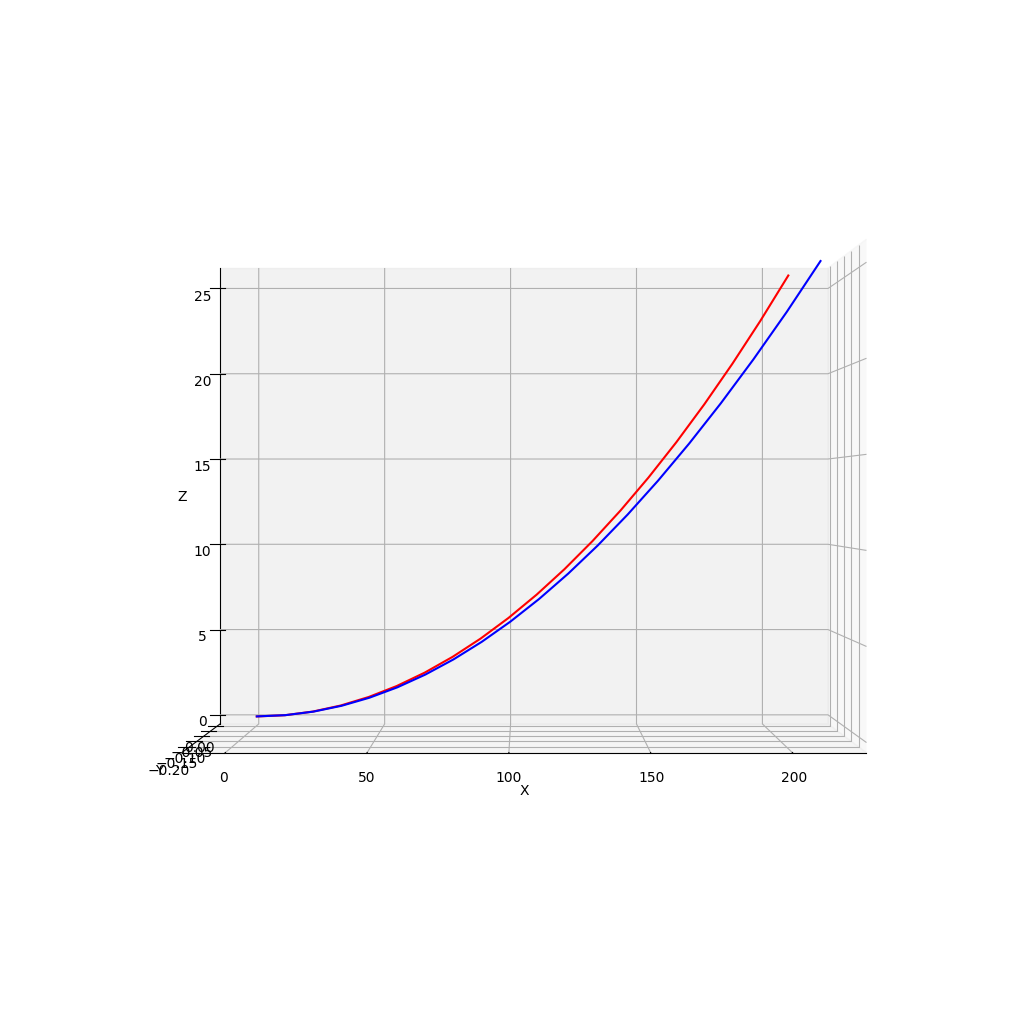

In [121]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
# ax.plot(x_fine, y_fine, z_fine, color='b')
# ax.view_init(-45,-45)
# ax.view_init(-30,-30)
ax.view_init(0,-90)
plt.show()

In [122]:
X,Y,Z

(array([-1.10028041e-04,  1.12495292e+01,  2.23823600e+01,  3.34914735e+01,
         4.45900941e+01,  5.56838514e+01,  6.67751079e+01,  7.78644509e+01,
         8.89516901e+01,  1.00036807e+02,  1.11119970e+02,  1.22201443e+02,
         1.33281679e+02,  1.44361362e+02,  1.55440743e+02,  1.66520526e+02,
         1.77601203e+02,  1.88683065e+02,  1.99766771e+02,  2.10681540e+02]),
 array([-1.10026534e-08,  3.32172754e-04, -5.15883555e-04, -2.86808071e-03,
        -6.63652947e-03, -1.18048103e-02, -1.83699285e-02, -2.63314684e-02,
        -3.56902287e-02, -4.64475844e-02, -5.86061859e-02, -7.21665924e-02,
        -8.71263302e-02, -1.03484255e-01, -1.21239076e-01, -1.40381062e-01,
        -1.60915637e-01, -1.82839739e-01, -2.06145123e-01, -2.30628011e-01]),
 array([2.42899874e-03, 7.31688719e-02, 2.84380588e-01, 6.34510268e-01,
        1.12399347e+00, 1.75282340e+00, 2.52099758e+00, 3.42849237e+00,
        4.47525914e+00, 5.66125510e+00, 6.98644947e+00, 8.45082362e+00,
        1.00543849e+

In [123]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [124]:
us=fin.T

In [125]:
us.shape

(240, 613)

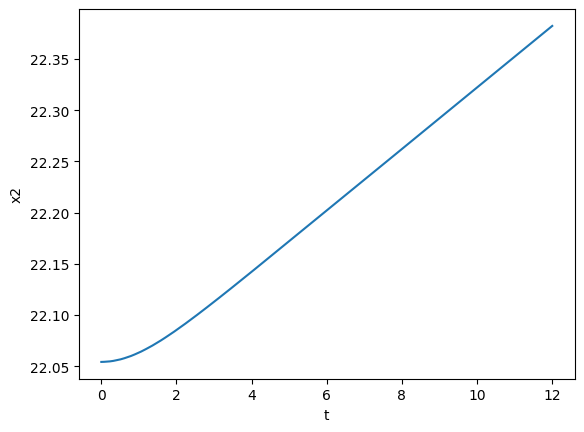

In [126]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

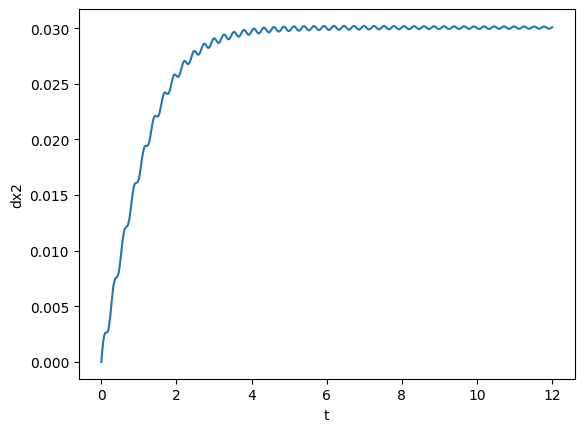

In [127]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

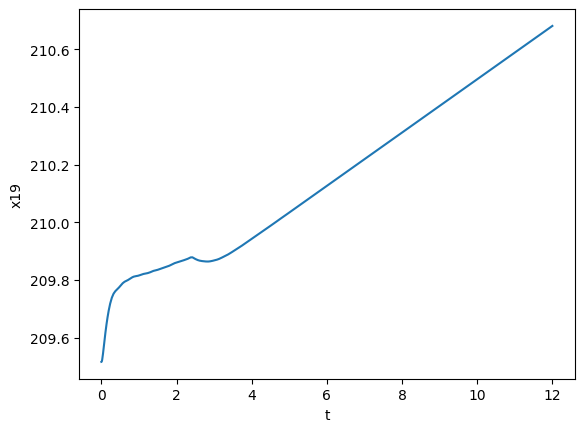

In [128]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

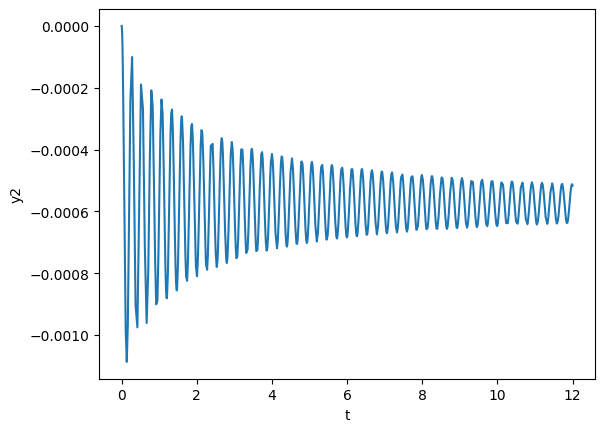

In [129]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

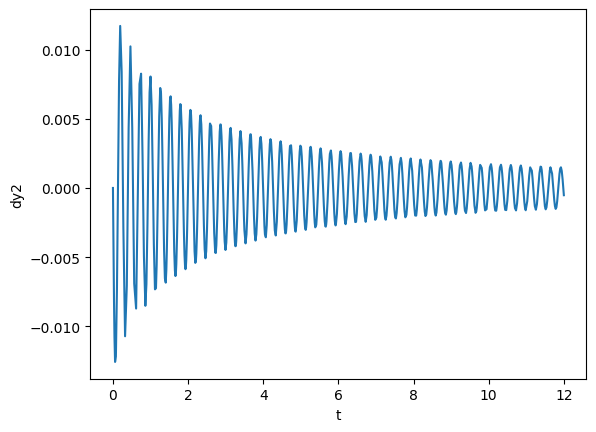

In [130]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

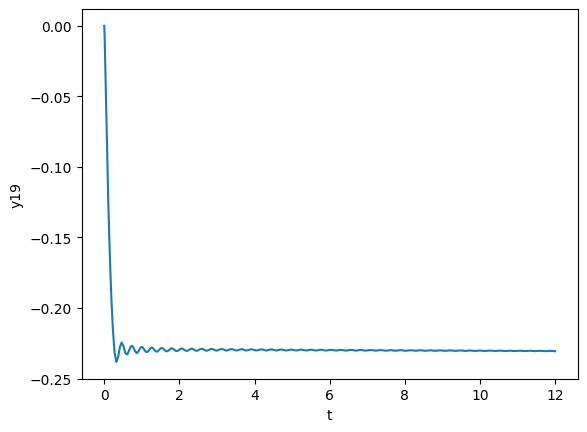

In [131]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

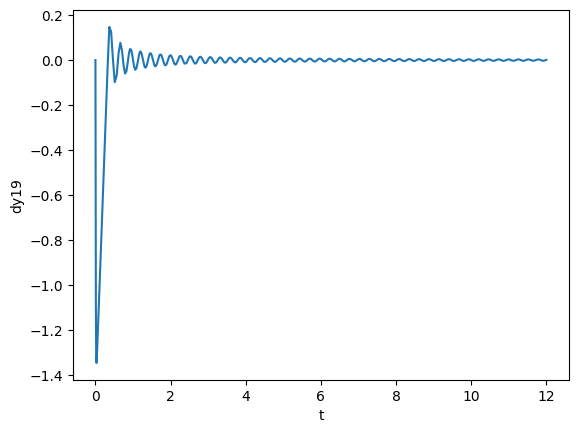

In [132]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

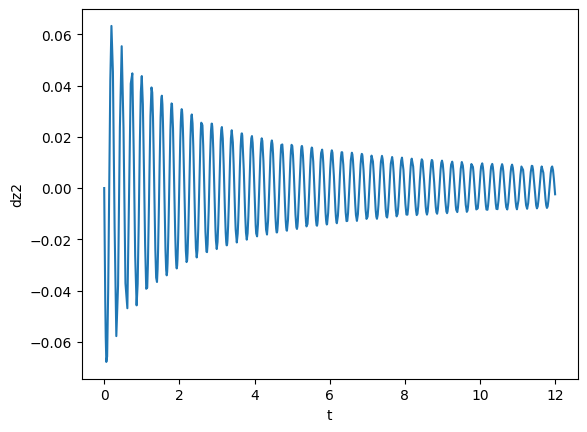

In [133]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

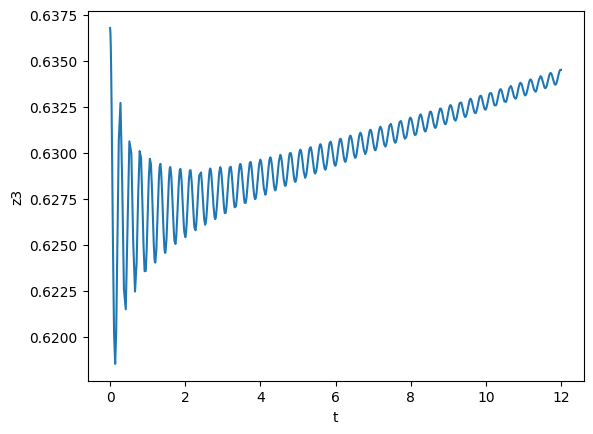

In [134]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

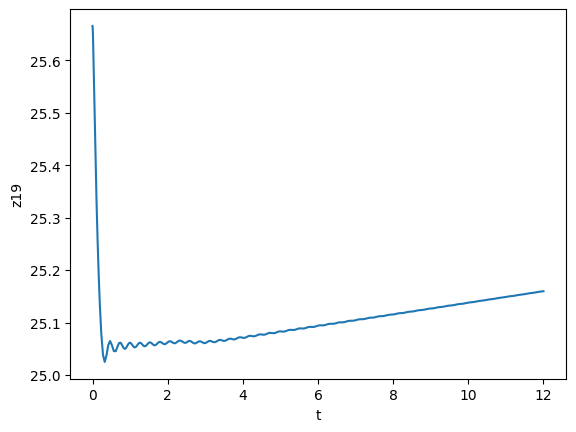

In [135]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

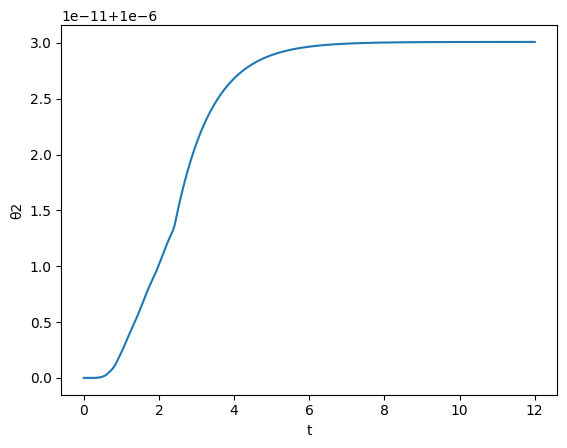

In [136]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

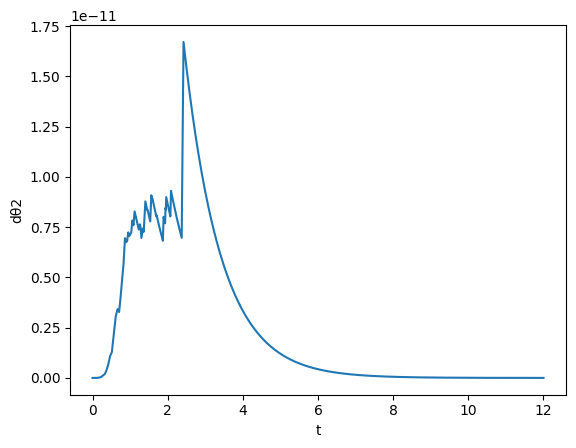

In [137]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

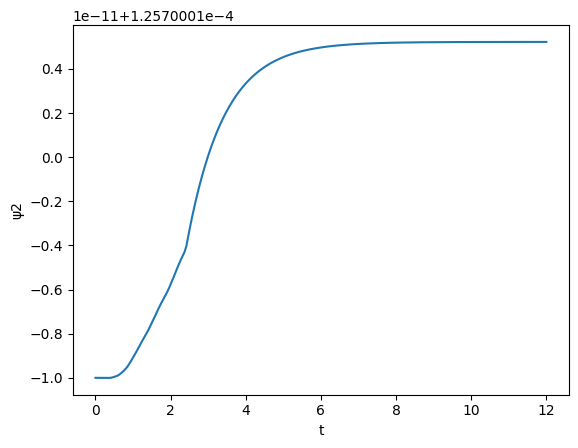

In [138]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

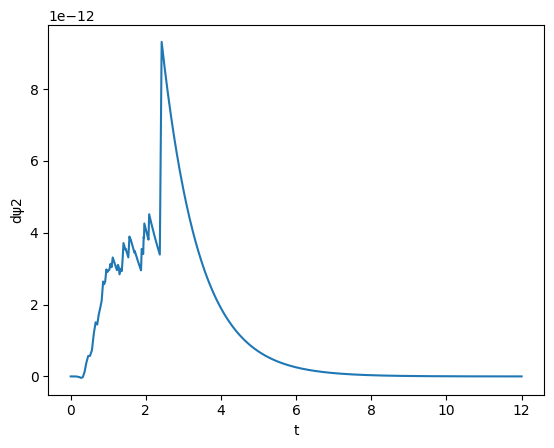

In [139]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

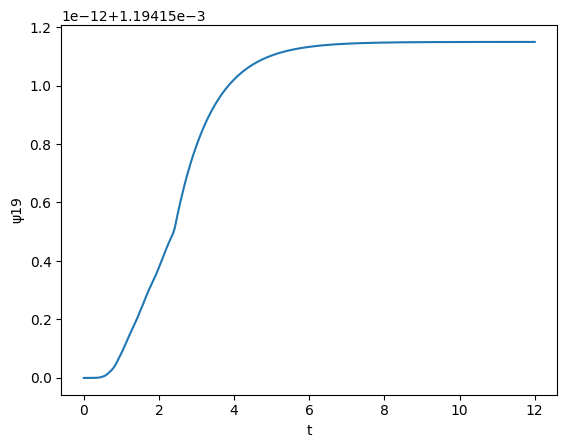

In [140]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [141]:
X010=us.T[:,0*N:1*N]

In [142]:
Y010=us.T[:,2*N:3*N]

In [143]:
Z010=us.T[:,4*N:5*N]

In [144]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()